In [1]:
import pandas as pd
import numpy as np
import pickle
import joblib
import xgboost as xgb
import itertools

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

# Tabular

### Loading Tabular Dataset

In [ ]:
mineral_cols = ["AU", "AG", "CU", "CO", "NI"]
target_cols = ["target_AU", "target_AG", "target_CU", "target_CO", "target_NI"]
target_col_string = "target_AU"
target_col = [target_col_string] # For single target prediction

df_processed = pd.read_csv('../processed(500)_geology_ml_training_data.csv', low_memory=False)
df_processed = df_processed[df_processed["hasImage"]] # Only get rows that have images
df_processed = df_processed.dropna(subset=target_col).copy()
df_processed[target_col_string] = (df_processed[target_col_string] > 0).astype(np.float32)

tabular_cols = [col for col in df_processed.columns if col not in  mineral_cols + target_cols + ['spatial_cluster', 'CODE_LITH', 'STRAT', 'Sample_ID', 'hasImage']]

bad_cols = df_processed[tabular_cols].select_dtypes(include=["object"]).columns
print(bad_cols)

df_processed[tabular_cols].head()

Index([], dtype='object')


,Easting,Northing,dist_fault,dist_cont,dist_fault_norm,dist_cont_norm,AU_missing,AG_missing,CU_missing,CO_missing,...,V3,V3A,V3B,V3D,V3F,V3G,V3H,V4,V4A,V4FO
4,-823281.410385,445223.349511,8620.008852,708.354658,0.040018,0.004530,0.000000,0.000000,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
6,-822577.690915,449159.895115,5937.687683,8.809315,0.027565,0.000056,0.333333,0.333333,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
7,-822498.982021,419697.736482,7963.856827,225.416115,0.036971,0.001442,0.000000,1.000000,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
8,-822352.108967,421386.167458,8951.045298,317.167447,0.041554,0.002028,0.000000,1.000000,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
9,-822343.618110,420346.833544,8246.925134,289.456545,0.038286,0.001851,0.000000,0.000000,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


### Splitting Tabular Dataset

In [3]:
# Splitting dataframe
train_df, test_df = train_test_split(df_processed, test_size=0.15, stratify=df_processed["target_AU"], random_state=42)

X = train_df[tabular_cols]
y = train_df[target_col_string].astype(int)

# Stratified K-Folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# folds = joblib.load("folds.pkl")
folds = list(skf.split(X, y))

## Training Model

### K-Folds evaluation

In [6]:
fold_results = []

for fold, (train_idx, val_idx) in enumerate(folds):

    X_train = X.iloc[train_idx]
    X_val   = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val   = y.iloc[val_idx]

    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos

    model = xgb.XGBClassifier(
        objective="binary:logistic",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0,
        reg_alpha=0,
        reg_lambda=1,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="aucpr"
    )

    model.fit(X_train, y_train)
    joblib.dump(model, f"xgboost_fold{fold}.joblib")

    # probability of positive class
    y_prob = model.predict_proba(X_val)[:, 1]

    roc = roc_auc_score(y_val, y_prob)
    pr  = average_precision_score(y_val, y_prob)

    fold_results.append({
        "fold": fold,
        "roc_auc": roc,
        "pr_auc": pr,
        "positive_rate": y_val.mean()
    })

    print(f"Fold {fold}")
    print(f"ROC AUC: {roc:.4f}")
    print(f"PR AUC:  {pr:.4f}")
    print(f"Positive rate: {y_val.mean():.4f}")
    print("-" * 30)

results_df = pd.DataFrame(fold_results)
results_df.to_csv("xgboost_5fold_results.csv", index=False)
print(results_df)
print("Mean ROC AUC:", results_df["roc_auc"].mean())
print("Mean PR AUC:", results_df["pr_auc"].mean())


Fold 0
ROC AUC: 0.8551
PR AUC:  0.3239
Positive rate: 0.0320
------------------------------
Fold 1
ROC AUC: 0.8621
PR AUC:  0.3103
Positive rate: 0.0316
------------------------------
Fold 2
ROC AUC: 0.8692
PR AUC:  0.3636
Positive rate: 0.0316
------------------------------
Fold 3
ROC AUC: 0.8672
PR AUC:  0.3550
Positive rate: 0.0316
------------------------------
Fold 4
ROC AUC: 0.8469
PR AUC:  0.2898
Positive rate: 0.0316
------------------------------
   fold   roc_auc    pr_auc  positive_rate
0     0  0.855075  0.323885       0.031970
1     1  0.862123  0.310345       0.031637
2     2  0.869152  0.363592       0.031637
3     3  0.867160  0.354959       0.031637
4     4  0.846888  0.289801       0.031637
Mean ROC AUC: 0.8600799063788305
Mean PR AUC: 0.32851638863259114


In [4]:
results_df = pd.read_csv("xgboost_5fold_results.csv")

print(results_df["roc_auc"].mean())
print(results_df["roc_auc"].std())

print(results_df["pr_auc"].mean())
print(results_df["pr_auc"].std())

0.8600799063788305
0.009160842718780052
0.32851638863259114
0.030740990717577323


### Hyperparameter Tuning

In [5]:
train_idx, val_idx = folds[0]

X_train = X.iloc[train_idx]
X_val   = X.iloc[val_idx]

y_train = y.iloc[train_idx]
y_val   = y.iloc[val_idx]

# Class imbalance weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

# Hyperparameter ranges
param_grid = {
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 300, 500],
    "min_child_weight": [1, 3, 5]
}

In [ ]:
results = []

# Iterate over every combination
for max_depth, learning_rate, n_estimators, min_child_weight in itertools.product(
    param_grid["max_depth"],
    param_grid["learning_rate"],
    param_grid["n_estimators"],
    param_grid["min_child_weight"]
):

    model = xgb.XGBClassifier(
        objective="binary:logistic",
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        min_child_weight=min_child_weight,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0,
        reg_alpha=0,
        reg_lambda=1,
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_val)[:, 1]

    roc = roc_auc_score(y_val, y_prob)
    pr = average_precision_score(y_val, y_prob)

    results.append({
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "n_estimators": n_estimators,
        "min_child_weight": min_child_weight,
        "roc_auc": roc,
        "pr_auc": pr
    })

    print(
        f"depth={max_depth:2d} | "
        f"lr={learning_rate:.2f} | "
        f"trees={n_estimators:3d} | "
        f"child={min_child_weight} | "
        f"ROC={roc:.4f} | "
        f"PR={pr:.4f}"
    )

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by the metric you care about most
results_df = results_df.sort_values("pr_auc", ascending=False)

print("\nTop 10 configurations:")
print(results_df.head(10))

# Save results
results_df.to_csv("xgboost_hyperparameter_search.csv", index=False)

# Best parameters
best = results_df.iloc[0]

print("\nBest configuration:")
print(best)

depth= 3 | lr=0.01 | trees=100 | child=1 | ROC=0.8297 | PR=0.2080
depth= 3 | lr=0.01 | trees=100 | child=3 | ROC=0.8297 | PR=0.2080
depth= 3 | lr=0.01 | trees=100 | child=5 | ROC=0.8293 | PR=0.2072
depth= 3 | lr=0.01 | trees=300 | child=1 | ROC=0.8469 | PR=0.2320
depth= 3 | lr=0.01 | trees=300 | child=3 | ROC=0.8470 | PR=0.2316
depth= 3 | lr=0.01 | trees=300 | child=5 | ROC=0.8470 | PR=0.2336
depth= 3 | lr=0.01 | trees=500 | child=1 | ROC=0.8533 | PR=0.2488
depth= 3 | lr=0.01 | trees=500 | child=3 | ROC=0.8536 | PR=0.2518
depth= 3 | lr=0.01 | trees=500 | child=5 | ROC=0.8531 | PR=0.2477
depth= 3 | lr=0.05 | trees=100 | child=1 | ROC=0.8523 | PR=0.2480
depth= 3 | lr=0.05 | trees=100 | child=3 | ROC=0.8524 | PR=0.2399
depth= 3 | lr=0.05 | trees=100 | child=5 | ROC=0.8520 | PR=0.2411
depth= 3 | lr=0.05 | trees=300 | child=1 | ROC=0.8618 | PR=0.2849
depth= 3 | lr=0.05 | trees=300 | child=3 | ROC=0.8626 | PR=0.2776
depth= 3 | lr=0.05 | trees=300 | child=5 | ROC=0.8597 | PR=0.2721
depth= 3 |

In [7]:
model = xgb.XGBClassifier(
        objective="binary:logistic",
        max_depth=5,
        learning_rate=0.1,
        n_estimators=300,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0,
        reg_alpha=0,
        reg_lambda=1,
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        random_state=42,
        n_jobs=-1
    )

model.fit(X_train, y_train)
joblib.dump(model, f"xgboost_best.joblib")

['xgboost_best.joblib']

### Feature importance

In [8]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(20))

        Feature  Importance
7    AG_missing    0.031657
165         S3E    0.026157
40          I1E    0.024537
101         I4N    0.020517
9    CO_missing    0.019467
173         S4G    0.018357
60          I2G    0.017568
199          S8    0.017076
96          I4I    0.017042
194         S7D    0.016789
181         S6D    0.016049
6    AU_missing    0.015866
10   NI_missing    0.015700
24           F1    0.015405
146         S1B    0.014980
73          I3D    0.014483
41          I1G    0.014255
160          S3    0.014196
229         V3F    0.014154
8    CU_missing    0.014127


In [9]:
importance["Group"] = "Lithology OHE"

importance.loc[
    importance["Feature"].str.endswith("_missing"),
    "Group"
] = "Missing indicators"

importance.loc[
    importance["Feature"].isin([
        "Easting",
        "Northing"
    ]),
    "Group"
] = "Coordinates"

importance.loc[
    importance["Feature"].str.contains("dist"),
    "Group"
] = "Distance"

group_importance = (
    importance
    .groupby("Group")["Importance"]
    .sum()
    .sort_values(ascending=False)
)

print(group_importance)

Group
Lithology OHE         0.843831
Missing indicators    0.096817
Distance              0.034035
Coordinates           0.025318
Name: Importance, dtype: float32


In [10]:
df_processed[tabular_cols].columns.values

array(['Easting', 'Northing', 'dist_fault', 'dist_cont',
       'dist_fault_norm', 'dist_cont_norm', 'AU_missing', 'AG_missing',
       'CU_missing', 'CO_missing', 'NI_missing', ' I2C', ' M22', ' S6D',
       '12G', '1B', 'BO', 'CB', 'CB+', 'CC', 'CL', 'CL+', 'CX', 'DM',
       'F1', 'F2', 'Fe+', 'GL', 'GP', 'GR', 'HB', 'HM+', 'HM++', 'I',
       'I1', 'I1A', 'I1B', 'I1C', 'I1D', 'I1D)', 'I1E', 'I1G', 'I1H',
       'I1I', 'I1L', 'I1M', 'I1P', 'I1Q', 'I1R', 'I1S', 'I1T', 'I2',
       'I2A', 'I2B', 'I2C', 'I2D', 'I2DF', 'I2DR', 'I2E', 'I2F', 'I2G',
       'I2H', 'I2I', 'I2J', 'I2M', 'I2N', 'I2O', 'I2P', 'I2Q', 'I3',
       'I3A', 'I3B', 'I3C', 'I3D', 'I3E', 'I3G', 'I3H', 'I3I', 'I3J',
       'I3K', 'I3N', 'I3O', 'I3OM', 'I3P', 'I3Q', 'I3Q.OF', 'I3R', 'I3T',
       'I4', 'I4A', 'I4B', 'I4C', 'I4D', 'I4E', 'I4F', 'I4G', 'I4I',
       'I4J', 'I4K', 'I4L', 'I4M', 'I4N', 'I4O', 'I4Q', 'I4SI', 'I4SU',
       'I4Z', 'I4ZM', 'I4ZN', 'M', 'M1', 'M10', 'M11', 'M12', 'M13',
       'M14', 'M15', 'M1

### Ablation Analysis

In [11]:
# Define feature groups
coordinate_cols = ["Easting", "Northing"]

missing_cols = [
    c for c in tabular_cols
    if c.endswith("_missing")
]

distance_cols = [
    c for c in tabular_cols
    if "dist" in c
]

lithology_cols = [
    c for c in tabular_cols
    if c not in coordinate_cols
    and c not in missing_cols
    and c not in distance_cols
]

feature_groups = {
    "Full model": [],
    "No Lithology OHE": lithology_cols,
    "No Missing indicators": missing_cols,
    "No Distance": distance_cols,
    "No Coordinates": coordinate_cols
}

ablation_results = []

for experiment_name, cols_to_remove in feature_groups.items():

    selected_cols = [
        c for c in tabular_cols
        if c not in cols_to_remove
    ]

    X_ablation = df_processed[selected_cols]
    y = df_processed["target_AU"].astype(int)

    X_train = X_ablation.iloc[train_idx]
    X_val   = X_ablation.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val   = y.iloc[val_idx]

    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos

    model = xgb.XGBClassifier(
        objective="binary:logistic",
        max_depth=5,
        learning_rate=0.1,
        n_estimators=300,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0,
        reg_alpha=0,
        reg_lambda=1,
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_val)[:, 1]

    roc = roc_auc_score(y_val, y_prob)
    pr = average_precision_score(y_val, y_prob)

    ablation_results.append({
        "experiment": experiment_name,
        "num_features": len(selected_cols),
        "roc_auc": roc,
        "pr_auc": pr
    })

    print(experiment_name)
    print("Features used:", len(selected_cols))
    print(f"ROC AUC: {roc:.4f}")
    print(f"PR AUC:  {pr:.4f}")
    print("-" * 40)

ablation_df = pd.DataFrame(ablation_results)

Full model
Features used: 235
ROC AUC: 0.8653
PR AUC:  0.3286
----------------------------------------
No Lithology OHE
Features used: 11
ROC AUC: 0.8656
PR AUC:  0.3491
----------------------------------------
No Missing indicators
Features used: 230
ROC AUC: 0.8288
PR AUC:  0.2070
----------------------------------------
No Distance
Features used: 231
ROC AUC: 0.8771
PR AUC:  0.3556
----------------------------------------
No Coordinates
Features used: 233
ROC AUC: 0.7971
PR AUC:  0.2261
----------------------------------------


In [12]:
# Compute performance drop relative to full model
baseline_pr = ablation_df.loc[
    ablation_df["experiment"] == "Full model",
    "pr_auc"
].values[0]

baseline_roc = ablation_df.loc[
    ablation_df["experiment"] == "Full model",
    "roc_auc"
].values[0]

ablation_df["delta_pr_auc"] = ablation_df["pr_auc"] - baseline_pr
ablation_df["delta_roc_auc"] = ablation_df["roc_auc"] - baseline_roc

ablation_df = ablation_df.sort_values("pr_auc", ascending=False)

print(ablation_df)

ablation_df.to_csv("xgboost_ablation_results.csv", index=False)

              experiment  num_features   roc_auc    pr_auc  delta_pr_auc  \
3            No Distance           231  0.877126  0.355591      0.027030   
1       No Lithology OHE            11  0.865610  0.349056      0.020494   
0             Full model           235  0.865254  0.328562      0.000000   
4         No Coordinates           233  0.797076  0.226123     -0.102438   
2  No Missing indicators           230  0.828848  0.206979     -0.121583   

   delta_roc_auc  
3       0.011872  
1       0.000356  
0       0.000000  
4      -0.068179  
2      -0.036406  


### Best model

In [13]:
X = train_df[tabular_cols]
y = train_df["target_AU"].astype(int)

neg = (y == 0).sum()
pos = (y == 1).sum()
scale_pos_weight = neg / pos

best_model = xgb.XGBClassifier(
    objective="binary:logistic",
    max_depth=5,
    learning_rate=0.1,
    n_estimators=300,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

best_model.fit(X, y)

joblib.dump(best_model, "xgboost_best_tuned.joblib")

print("Model trained successfully.")

Model trained successfully.


### Failure Analysis

In [15]:
X_test = test_df[tabular_cols]
y_test = test_df["target_AU"].astype(int)

y_prob = best_model.predict_proba(X_test)[:, 1]

y_pred = (y_prob >= 0.5).astype(int)

results = X_test.copy()

results["Actual"] = y_test.values
results["Predicted"] = y_pred
results["Probability"] = y_prob

errors = results[
    results["Actual"] != results["Predicted"]
]

false_positive = errors[
    (errors["Actual"] == 0) &
    (errors["Predicted"] == 1)
]

false_negative = errors[
    (errors["Actual"] == 1) &
    (errors["Predicted"] == 0)
]

In [28]:
# 1) Highest-confidence FP
example_fp = false_positive.sort_values(
    "Probability",
    ascending=False
).iloc[0]

# 2) Highest-confidence FN
example_fn = false_negative.sort_values(
    "Probability",
    ascending=True
).iloc[0]

# 3) Borderline error (closest to 0.5)
example_borderline = errors.iloc[
    (errors["Probability"] - 0.5).abs().argmin()
]

In [29]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print(cm)

print(classification_report(y_test, y_pred))

[[2400   86]
 [  37   44]]
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      2486
           1       0.34      0.54      0.42        81

    accuracy                           0.95      2567
   macro avg       0.66      0.75      0.70      2567
weighted avg       0.96      0.95      0.96      2567



In [26]:
import shap

explainer = shap.TreeExplainer(best_model)

shap_values = explainer(X_test)


In [35]:
def explain_failure(example, title):

    position = X_test.index.get_loc(example.name)

    print("=" * 60)
    print(title)
    print("=" * 60)

    print("Record index:", example.name)
    print("Actual:", example["Actual"])
    print("Predicted:", example["Predicted"])
    print("Probability:", round(example["Probability"], 4))

    shap.plots.waterfall(
        shap_values[position],
        max_display=10
    )

High-confidence False Positive
Record index: 517
Actual: 0.0
Predicted: 1.0
Probability: 0.9595


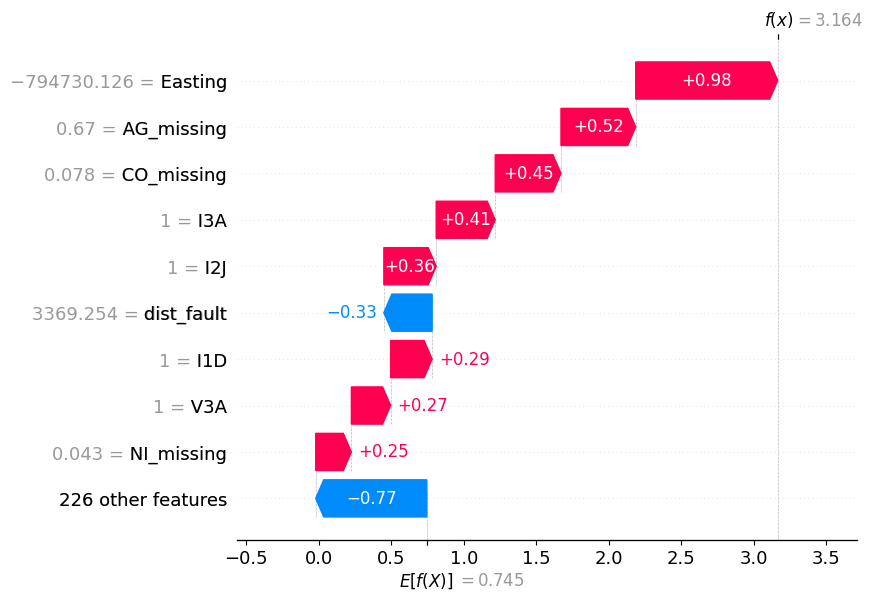

High-confidence False Negative
Record index: 21200
Actual: 1.0
Predicted: 0.0
Probability: 0.008


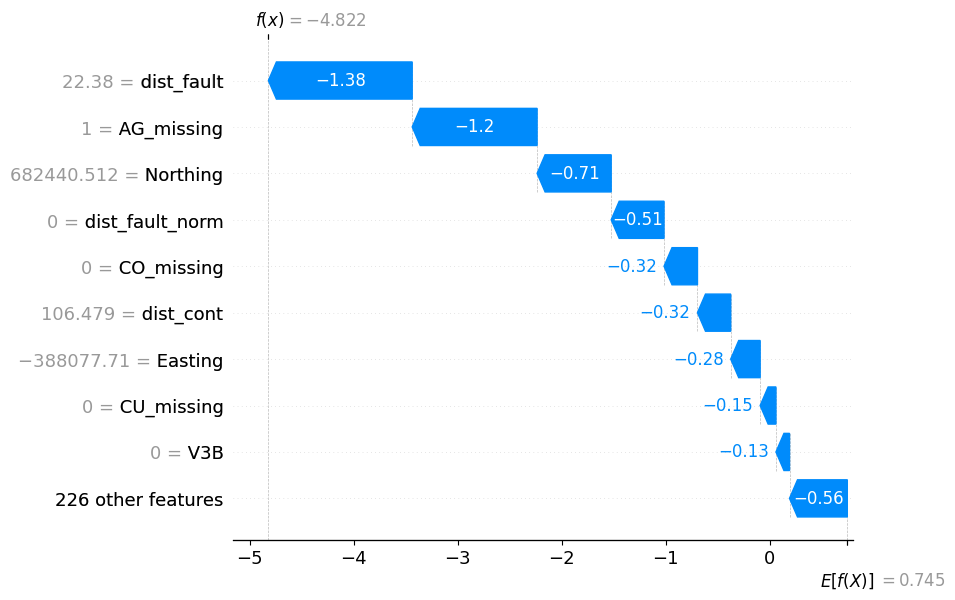

Borderline Prediction
Record index: 11332
Actual: 0.0
Predicted: 1.0
Probability: 0.5003


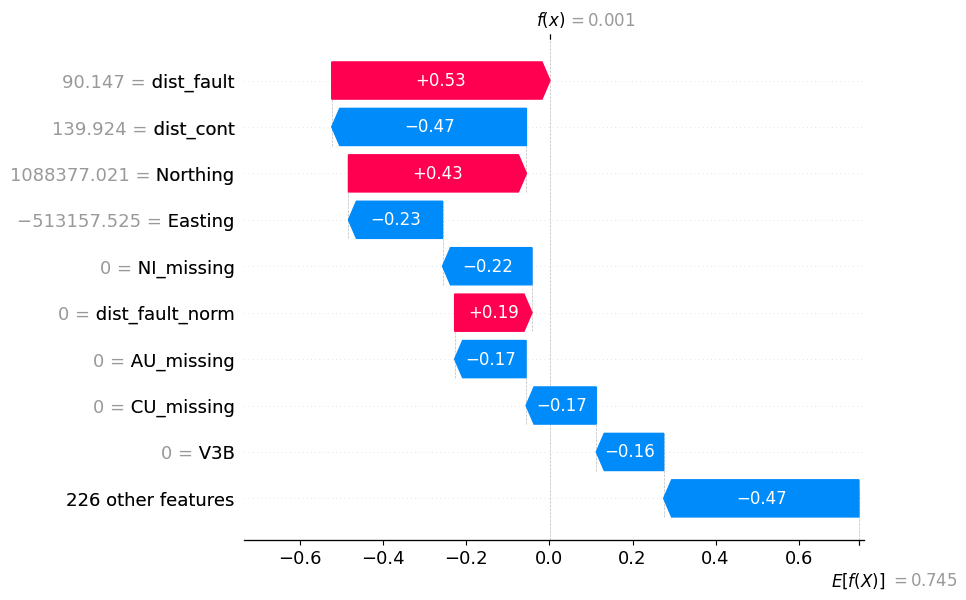

In [37]:
explain_failure(example_fp, "High-confidence False Positive")

explain_failure(example_fn, "High-confidence False Negative")

explain_failure(example_borderline, "Borderline Prediction")